In [ ]:
import os

DATA_DIR = "./data"
OUTPUT_DIR = "./outputs"

In [ ]:
import pandas as pd

df = pd.read_excel(
    os.path.join(OUTPUT_DIR, "dataset_with_sentiment.xlsx")
)

print(df.shape)
df.head()

(5715, 26)


,tweet_id,display_name,username,followers,tweet,created_at,lang,user_location,tweet_location,likes,...,location_clean,city_clean,sentiment_roberta,confidence_roberta,polarity_roberta,sentiment_model2,confidence_model2,polarity_model2,sentiment,sentiment_score
0,1406970754688717056,Яizal do,afrkml,350301,Gejala yg ditimbulkan memang umum dan sudah di...,Mon Jun 21 13:42:22 +0000 2021,in,Dukung kami di sini →,NaN,245,...,dukung kami di sini,NaN,negative,0.752307,-0.752307,negative,0.995110,-0.995110,negative,-0.995110
1,1409518162362568960,🍒,claudiaars__,230,Until this minute masih ga habis pikir bisa2ny...,Mon Jun 28 14:24:52 +0000 2021,in,Jakarta,NaN,0,...,jakarta,jakarta,negative,0.996685,-0.996685,negative,0.619597,-0.619597,negative,-0.619597
2,1408483130994946048,R30_K03 🇮🇩,ryuuken86,24,Hari jum'at 24 juni. Guru SMP ku meninggal di ...,Fri Jun 25 17:52:01 +0000 2021,in,Indonesia,NaN,0,...,indonesia,NaN,negative,0.616726,-0.616726,positive,0.891653,0.891653,positive,0.891653
3,1409494375294390016,M Taufik Zoelkifli,emtezet,2127,Singapura sudah akan beranjak dari Pandemi men...,Mon Jun 28 12:50:20 +0000 2021,in,Jakarta,"Cempaka Putih, Indonesia",2,...,cempaka putih indonesia,NaN,positive,0.778616,0.778616,positive,0.954192,0.954192,positive,0.954192
4,1407938212631237120,rahardjoguyub,guyubrahardjo,598,@CNNIndonesia @PutraWadapi Kondisi jakarta yg ...,Thu Jun 24 05:46:42 +0000 2021,in,"DKI Jakarta, Indonesia",NaN,0,...,dki jakarta indonesia,jakarta,neutral,0.654501,0.000000,neutral,0.889500,0.000000,neutral,0.000000


In [2]:
# --- Unmatched-location bias check (for Reviewer 2 Comment #7) ---
matched_group = df[df["city_clean"].notna()].copy()
unmatched_group = df[df["city_clean"].isna()].copy()

print("Matched (location-identified):", len(matched_group))
print("Unmatched (no city match):", len(unmatched_group))
print()

print("=== Sentiment distribution: MATCHED ===")
print(matched_group["sentiment"].value_counts())
print(matched_group["sentiment"].value_counts(normalize=True) * 100)
print()

print("=== Sentiment distribution: UNMATCHED ===")
print(unmatched_group["sentiment"].value_counts())
print(unmatched_group["sentiment"].value_counts(normalize=True) * 100)

Matched (location-identified): 3327
Unmatched (no city match): 2388

=== Sentiment distribution: MATCHED ===
sentiment
neutral     2397
positive     501
negative     429
Name: count, dtype: int64
sentiment
neutral     72.046889
positive    15.058611
negative    12.894500
Name: proportion, dtype: float64

=== Sentiment distribution: UNMATCHED ===
sentiment
neutral     1331
negative     732
positive     325
Name: count, dtype: int64
sentiment
neutral     55.737018
negative    30.653266
positive    13.609715
Name: proportion, dtype: float64


In [3]:
from scipy.stats import chi2_contingency

contingency = pd.crosstab(
    df["city_clean"].notna().map({True: "matched", False: "unmatched"}),
    df["sentiment"]
)
print(contingency)
print()

chi2, p_value, dof, expected = chi2_contingency(contingency)
print(f"Chi-square statistic: {chi2:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"Degrees of freedom: {dof}")

sentiment   negative  neutral  positive
city_clean                             
matched          429     2397       501
unmatched        732     1331       325

Chi-square statistic: 274.5244
p-value: 0.000000
Degrees of freedom: 2


In [4]:
# What does unmatched location text actually look like?
unmatched_text = df[df["city_clean"].isna()]["location_clean"].value_counts().head(30)
print(unmatched_text)

location_clean
indonesia                         602
t                                  51
wherever you are                   35
pulo gadung indonesia              25
malaysia                           24
sheher                             22
bali indonesia                     22
jalan dr sumarno pulogebang        22
nkri                               18
kalimantan barat indonesia         17
aceh                               16
vda                                15
south borneo indonesia             13
jawa tengah indonesia              13
kebon jeruk indonesia              13
jl blustru no                      12
departemen matematika fmipa ui     11
jawa timur                         11
blok a lantai  walikota jb         11
bali                               10
suryakencana pajarakan             10
ilha solteira brasil                9
jl rumah sakit no                   9
dili timorleste                     9
karangwangkal purwokerto            8
kalimantan tengah indonesia        

In [2]:
#take only data with code
spatial_df = (
    df[
        df["city_clean"].notna()
    ]
    .copy()
)

print(
    "Spatial records:",
    len(spatial_df)
)

Spatial records: 3327


In [3]:
city_ref = pd.read_csv(
    "daftar-nama-daerah.csv"
)

# hanya kota/kabupaten
city_ref = city_ref[
    city_ref["type"] == 2
].copy()

In [4]:
city_ref["city_clean"] = (
    city_ref["name"]
    .str.lower()
    .str.replace("kabupaten ", "", regex=False)
    .str.replace("kota ", "", regex=False)
    .str.strip()
)

# normalisasi jakarta
city_ref["city_clean"] = city_ref["city_clean"].str.replace(
    r"jakarta.*", "jakarta", regex=True
)

In [5]:
city_coord = city_ref[
    [
        "city_clean",
        "latitude",
        "longitude"
    ]
].drop_duplicates()

In [6]:
city_coord[
    city_coord["city_clean"]
    == "jakarta"
]

,city_clean,latitude,longitude
223,jakarta,-6.332973,106.807915
224,jakarta,-6.211544,106.845172


In [7]:
city_coord = (
    city_ref
    .groupby("city_clean")
    [
        ["latitude", "longitude"]
    ]
    .mean()
    .reset_index()
)

In [8]:
city_coord[
    city_coord["city_clean"] == "jakarta"
]

,city_clean,latitude,longitude
145,jakarta,-6.23583,106.837721


Tweet Distribution By City

In [9]:
city_distribution = (
    spatial_df["city_clean"]
    .value_counts()
    .reset_index()
)

city_distribution.columns = [
    "city",
    "total_tweets"
]

city_distribution.head(20)

,city,total_tweets
0,jakarta,1411
1,surabaya,160
2,bandar lampung,146
3,yogyakarta,138
4,bandung,109
5,denpasar,100
6,depok,66
7,malang,60
8,semarang,56
9,tangerang,49


In [10]:
city_map = city_distribution.merge(
    city_coord,
    left_on="city",
    right_on="city_clean",
    how="left"
)

city_map.head()

,city,total_tweets,city_clean,latitude,longitude
0,jakarta,1411,jakarta,-6.235830,106.837721
1,surabaya,160,surabaya,-7.289166,112.734398
2,bandar lampung,146,bandar lampung,-5.450000,105.266667
3,yogyakarta,138,yogyakarta,-7.797224,110.368797
4,bandung,109,bandung,-6.914744,107.609811


In [11]:
city_map[
    city_map["latitude"].isna()
]

,city,total_tweets,city_clean,latitude,longitude


In [ ]:
city_distribution.to_excel(
    os.path.join(OUTPUT_DIR, "city_distribution.xlsx"),
    index=False
)

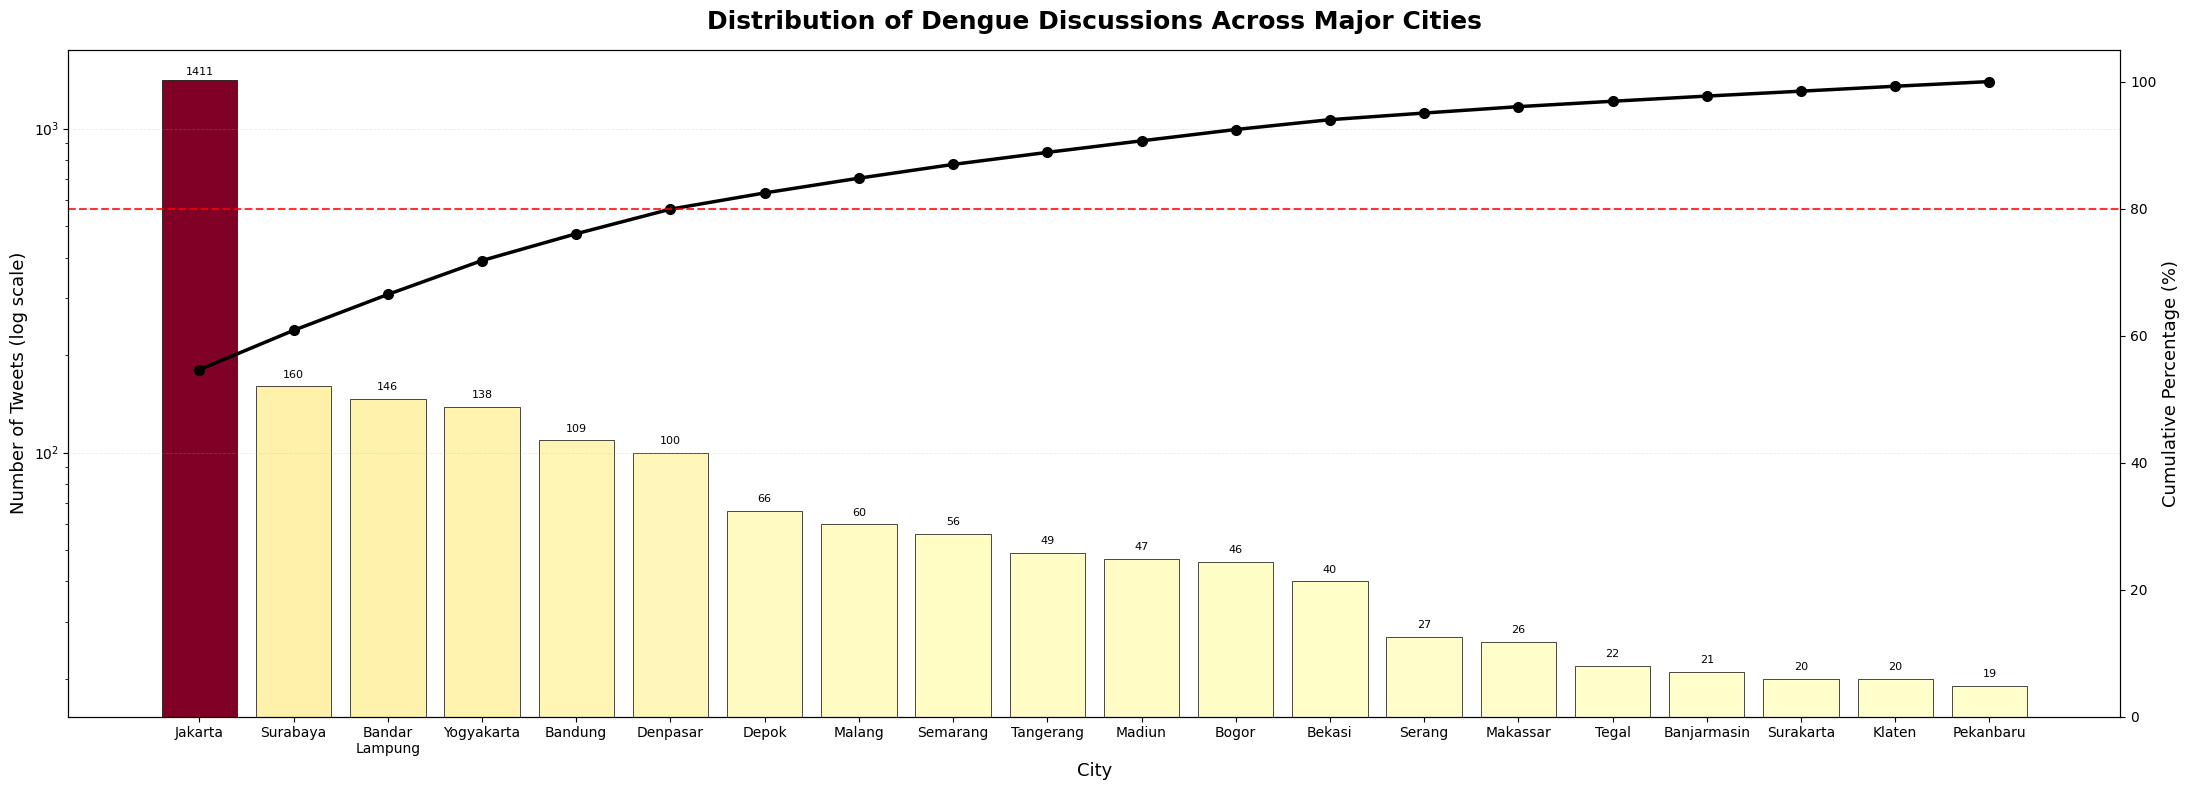

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# =====================================
# DATA
# =====================================

top20 = city_distribution.head(20).copy()

# cumulative percentage
top20["cum_pct"] = (
    top20["total_tweets"].cumsum()
    /
    top20["total_tweets"].sum()
) * 100

# city labels (multi-line)
top20["city_label"] = (
    top20["city"]
    .str.title()
    .str.replace(" ", "\n")
)

# =====================================
# COLORS
# =====================================

norm = mcolors.Normalize(
    vmin=top20["total_tweets"].min(),
    vmax=top20["total_tweets"].max()
)

colors = cm.YlOrRd(
    norm(top20["total_tweets"])
)

# =====================================
# FIGURE
# =====================================

fig, ax1 = plt.subplots(
    figsize=(22, 8)
)

# =====================================
# BAR CHART
# =====================================

bars = ax1.bar(
    top20["city_label"],
    top20["total_tweets"],
    color=colors,
    edgecolor="black",
    linewidth=0.5
)

# log scale
ax1.set_yscale("log")

ax1.set_ylabel(
    "Number of Tweets (log scale)",
    fontsize=13
)

ax1.set_xlabel(
    "City",
    fontsize=13
)

# grid
ax1.grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    alpha=0.25
)

# value labels
for bar in bars:

    height = bar.get_height()

    multiplier = (
        1.02
        if height == top20["total_tweets"].max()
        else 1.05
    )

    ax1.text(
        bar.get_x() + bar.get_width()/2,
        height * multiplier,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=8
    )

# =====================================
# CUMULATIVE CONTRIBUTION LINE
# =====================================

ax2 = ax1.twinx()

ax2.plot(
    top20["city_label"],
    top20["cum_pct"],
    color="black",
    marker="o",
    markersize=7,
    linewidth=2.5
)

ax2.set_ylabel(
    "Cumulative Percentage (%)",
    fontsize=13
)

ax2.set_ylim(
    0,
    105
)

# =====================================
# 80% THRESHOLD
# =====================================

ax2.axhline(
    y=80,
    color="red",
    linestyle="--",
    linewidth=1.5,
    alpha=0.8
)

# =====================================
# TITLE
# =====================================

plt.title(
    "Distribution of Dengue Discussions Across Major Cities",
    fontsize=18,
    weight="bold",
    pad=15
)

# =====================================
# X LABELS
# =====================================

plt.xticks(
    rotation=0,
    fontsize=9
)

# =====================================
# LAYOUT
# =====================================

plt.subplots_adjust(
    bottom=0.20,
    top=0.90
)

plt.tight_layout()

# =====================================
# EXPORT
# =====================================

plt.savefig(
    "pareto_city_distribution_final.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
import plotly.express as px
import plotly.io as pio
import numpy as np

# log transform
city_map["bubble_size"] = np.log1p(
    city_map["total_tweets"]
)

city_map["tweet_log"] = np.log1p(
    city_map["total_tweets"]
)

fig = px.scatter_geo(
    city_map,
    lat="latitude",
    lon="longitude",
    size="bubble_size",
    size_max=25,
    color="tweet_log",
    color_continuous_scale="YlOrRd",
    hover_name="city",
    hover_data={
        "total_tweets": True,
        "latitude": False,
        "longitude": False,
        "bubble_size": False,
        "tweet_log": False
    },
    projection="natural earth",
    title="Spatial Distribution of Dengue Discussions by City"
)

fig.update_traces(
    marker=dict(
        opacity=0.8,
        line=dict(
            width=0.5,
            color="black"
        )
    )
)

fig.update_geos(
    center=dict(
        lat=-2,
        lon=118
    ),
    lataxis_range=[-12, 8],
    lonaxis_range=[94, 142],
    showcountries=True,
    showcoastlines=True,
    showland=True
)

fig.update_layout(
    coloraxis_colorbar=dict(
        title="Log(Tweets)"
    )
)

pio.renderers.default = "browser"
fig.show()

Sentiment Distribution by City

In [15]:
city_sentiment = (
    spatial_df
    .groupby(
        [
            "city_clean",
            "sentiment"
        ]
    )
    .size()
    .unstack(fill_value=0)
)

city_sentiment.head()

sentiment,negative,neutral,positive
city_clean,,,
aceh besar,1,0,0
aceh tenggara,0,1,0
agam,0,1,0
ambon,0,4,3
asmat,0,2,0


In [16]:
city_sentiment["total"] = (
    city_sentiment.sum(axis=1)
)

In [17]:
for col in [
    "positive",
    "neutral",
    "negative"
]:
    
    city_sentiment[
        f"{col}_ratio"
    ] = (
        city_sentiment[col]
        /
        city_sentiment["total"]
    )

In [18]:
city_sentiment[
    "dominant_sentiment"
] = (
    city_sentiment[
        [
            "positive",
            "neutral",
            "negative"
        ]
    ]
    .idxmax(axis=1)
)

In [19]:
city_sentiment.head()

sentiment,negative,neutral,positive,total,positive_ratio,neutral_ratio,negative_ratio,dominant_sentiment
city_clean,,,,,,,,
aceh besar,1,0,0,1,0.000000,0.000000,1.0,negative
aceh tenggara,0,1,0,1,0.000000,1.000000,0.0,neutral
agam,0,1,0,1,0.000000,1.000000,0.0,neutral
ambon,0,4,3,7,0.428571,0.571429,0.0,neutral
asmat,0,2,0,2,0.000000,1.000000,0.0,neutral


In [ ]:
city_sentiment.to_excel(
    os.path.join(OUTPUT_DIR, "city_sentiment.xlsx")
)

In [20]:
#dominant sentiment map
import plotly.express as px
import numpy as np

city_sentiment_map = city_sentiment.merge(
    city_coord,
    on="city_clean",
    how="left"
)

city_sentiment_map["bubble_size"] = np.log1p(
    city_sentiment_map["total"]
)

fig = px.scatter_geo(
    city_sentiment_map,
    lat="latitude",
    lon="longitude",
    color="dominant_sentiment",
    size="bubble_size",
    hover_name="city_clean",
    hover_data=[
        "positive",
        "neutral",
        "negative",
        "total"
    ],
    projection="natural earth",
    title="Dominant Sentiment Distribution of Dengue Discussions"
)

fig.update_geos(
    lataxis_range=[-12,8],
    lonaxis_range=[94,142]
)

fig.show()

In [21]:
city_sentiment.head()

sentiment,negative,neutral,positive,total,positive_ratio,neutral_ratio,negative_ratio,dominant_sentiment
city_clean,,,,,,,,
aceh besar,1,0,0,1,0.000000,0.000000,1.0,negative
aceh tenggara,0,1,0,1,0.000000,1.000000,0.0,neutral
agam,0,1,0,1,0.000000,1.000000,0.0,neutral
ambon,0,4,3,7,0.428571,0.571429,0.0,neutral
asmat,0,2,0,2,0.000000,1.000000,0.0,neutral


In [22]:
print(city_sentiment.columns)

Index(['negative', 'neutral', 'positive', 'total', 'positive_ratio',
       'neutral_ratio', 'negative_ratio', 'dominant_sentiment'],
      dtype='str', name='sentiment')


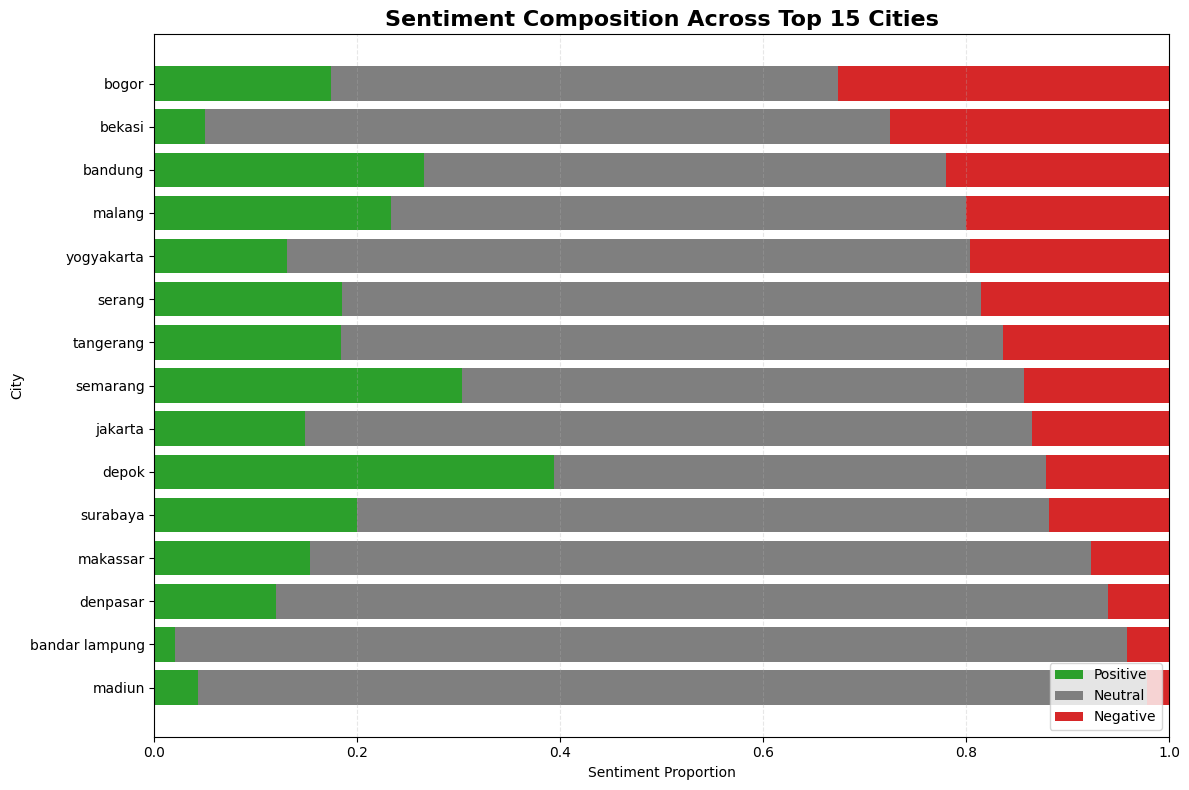

In [23]:
import matplotlib.pyplot as plt

top15 = (
    city_sentiment
    .reset_index()
    .sort_values("total", ascending=False)
    .head(15)
)

top15 = top15.sort_values(
    "negative_ratio"
)

plt.figure(figsize=(12,8))

plt.barh(
    top15["city_clean"],
    top15["positive_ratio"],
    color="#2ca02c",
    label="Positive"
)

plt.barh(
    top15["city_clean"],
    top15["neutral_ratio"],
    left=top15["positive_ratio"],
    color="#7f7f7f",
    label="Neutral"
)

plt.barh(
    top15["city_clean"],
    top15["negative_ratio"],
    left=(
        top15["positive_ratio"]
        +
        top15["neutral_ratio"]
    ),
    color="#d62728",
    label="Negative"
)

plt.xlabel(
    "Sentiment Proportion"
)

plt.ylabel(
    "City"
)

plt.title(
    "Sentiment Composition Across Top 15 Cities",
    fontsize=16,
    weight="bold"
)

plt.xlim(0,1)

plt.legend(
    loc="lower right"
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.show()

Network Metrics by City

In [24]:
import networkx as nx
from community import community_louvain

In [ ]:
edges_data = pd.read_excel(
    os.path.join(OUTPUT_DIR, "weighted_edges.xlsx")
)

In [26]:
#build complete network
G_complete = nx.DiGraph()

for _, row in edges_data.iterrows():

    G_complete.add_edge(
        row["source"],
        row["target"],
        weight=row["weight"]
    )

In [27]:
#hitung ukuran network tiap kota
city_network_size = []

for city in df["city_clean"].dropna().unique():

    city_users = (
        df[
            df["city_clean"] == city
        ]["username"]
        .dropna()
        .unique()
    )

    G_city = (
        G_complete
        .subgraph(city_users)
        .copy()
    )

    city_network_size.append({

        "city": city,

        "nodes":
            G_city.number_of_nodes(),

        "edges":
            G_city.number_of_edges()

    })

city_network_size = pd.DataFrame(
    city_network_size
)

In [28]:
city_network_size = (
    city_network_size[
        city_network_size["nodes"] >=10
    ]
)

In [29]:
city_network_size.sort_values(
    "nodes",
    ascending=False
)

,city,nodes,edges
0,jakarta,145,80
2,yogyakarta,29,15
20,surabaya,26,11
25,bandung,21,6
14,malang,18,7
28,semarang,12,7
7,depok,12,9
19,bekasi,11,4
29,denpasar,10,4


In [30]:
selected_cities = pd.DataFrame({

    "city": [
        "jakarta",
        "yogyakarta",
        "surabaya",

        "bandung",
        "malang",
        "semarang",

        "depok",
        "bekasi",
        "denpasar"
    ],

    "group": [
        "High",
        "High",
        "High",

        "Medium",
        "Medium",
        "Medium",

        "Low",
        "Low",
        "Low"
    ]
})

In [31]:
selected_cities

,city,group
0,jakarta,High
1,yogyakarta,High
2,surabaya,High
3,bandung,Medium
4,malang,Medium
5,semarang,Medium
6,depok,Low
7,bekasi,Low
8,denpasar,Low


In [32]:
user_city = (
    df[
        ["username", "city_clean"]
    ]
    .dropna()
    .drop_duplicates()
)

In [33]:
edges_city = edges_data.merge(
    user_city,
    left_on="source",
    right_on="username",
    how="left"
)

edges_city = edges_city.rename(
    columns={
        "city_clean":"city_source"
    }
)

edges_city = edges_city.drop(
    columns=["username"]
)

In [34]:
edges_city = edges_city.merge(
    user_city,
    left_on="target",
    right_on="username",
    how="left"
)

edges_city = edges_city.rename(
    columns={
        "city_clean":"city_target"
    }
)

edges_city = edges_city.drop(
    columns=["username"]
)

In [35]:
print(edges_city.columns)

Index(['source', 'target', 'sentiment', 'weight', 'city_source',
       'city_target'],
      dtype='str')


In [36]:
import networkx as nx
from community import community_louvain

city_metrics = []

for city in selected_cities["city"]:

    print(f"Processing {city}...")

    # ambil edge yang berasal dari kota tersebut
    city_edges = (
        edges_city[
            edges_city["city_source"] == city
        ]
        .copy()
    )

    # skip jika tidak ada edge
    if len(city_edges) == 0:
        continue

    # build graph
    G_city = nx.from_pandas_edgelist(
        city_edges,
        source="source",
        target="target",
        edge_attr="weight",
        create_using=nx.DiGraph()
    )

    nodes = G_city.number_of_nodes()
    edges_num = G_city.number_of_edges()

    # Average Degree
    avg_degree = (
        sum(
            dict(
                G_city.degree()
            ).values()
        )
        / nodes
    )

    # Density
    density = nx.density(
        G_city
    )

    # Community Detection
    G_undirected = (
        G_city.to_undirected()
    )

    try:

        partition = (
            community_louvain
            .best_partition(
                G_undirected
            )
        )

        communities = len(
            set(
                partition.values()
            )
        )

        modularity = (
            community_louvain
            .modularity(
                partition,
                G_undirected
            )
        )

    except:

        communities = None
        modularity = None

    city_metrics.append({

        "city": city,

        "nodes":
            nodes,

        "edges":
            edges_num,

        "average_degree":
            round(avg_degree,4),

        "density":
            round(density,4),

        "communities":
            communities,

        "modularity":
            round(modularity,4)
            if modularity is not None
            else None

    })

Processing jakarta...
Processing yogyakarta...
Processing surabaya...
Processing bandung...
Processing malang...
Processing semarang...
Processing depok...
Processing bekasi...
Processing denpasar...


In [37]:
city_metrics_df = pd.DataFrame(
    city_metrics
)

In [38]:
city_metrics_df = (
    city_metrics_df.merge(
        selected_cities[
            ["city", "group"]
        ],
        on="city",
        how="left"
    )
)

In [39]:
city_metrics_df = (
    city_metrics_df.sort_values(
        ["group","nodes"],
        ascending=[True,False]
    )
)

city_metrics_df

,city,nodes,edges,average_degree,density,communities,modularity,group
0,jakarta,273,223,1.6337,0.0030,126,0.9798,High
1,yogyakarta,59,45,1.5254,0.0132,29,0.9461,High
2,surabaya,51,39,1.5294,0.0153,23,0.9443,High
8,denpasar,22,16,1.4545,0.0346,10,0.8800,Low
7,bekasi,18,11,1.2222,0.0359,11,0.8978,Low
6,depok,17,14,1.6471,0.0515,12,0.9025,Low
3,bandung,43,31,1.4419,0.0172,17,0.9150,Medium
4,malang,34,28,1.6471,0.0250,15,0.8154,Medium
5,semarang,18,14,1.5556,0.0458,9,0.8519,Medium


In [ ]:
city_metrics_df.to_excel(
    os.path.join(OUTPUT_DIR, "city_metrics.xlsx")
)

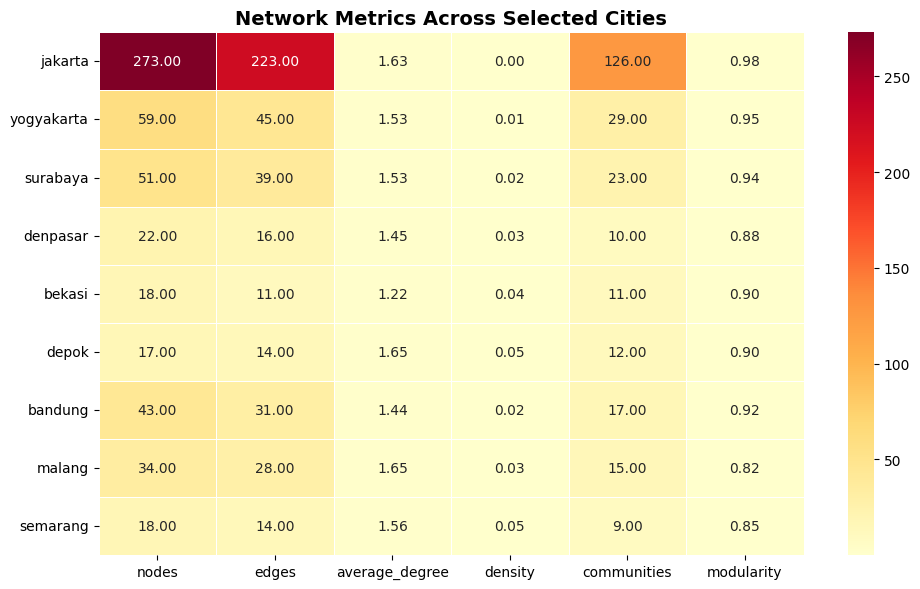

In [120]:
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_data = (
    city_metrics_df[
        [
            "city",
            "nodes",
            "edges",
            "average_degree",
            "density",
            "communities",
            "modularity"
        ]
    ]
    .set_index("city")
)

plt.figure(figsize=(10,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="YlOrRd",
    fmt=".2f",
    linewidths=.5
)

plt.title(
    "Network Metrics Across Selected Cities",
    fontsize=14,
    weight="bold"
)

plt.ylabel("")
plt.tight_layout()
plt.show()

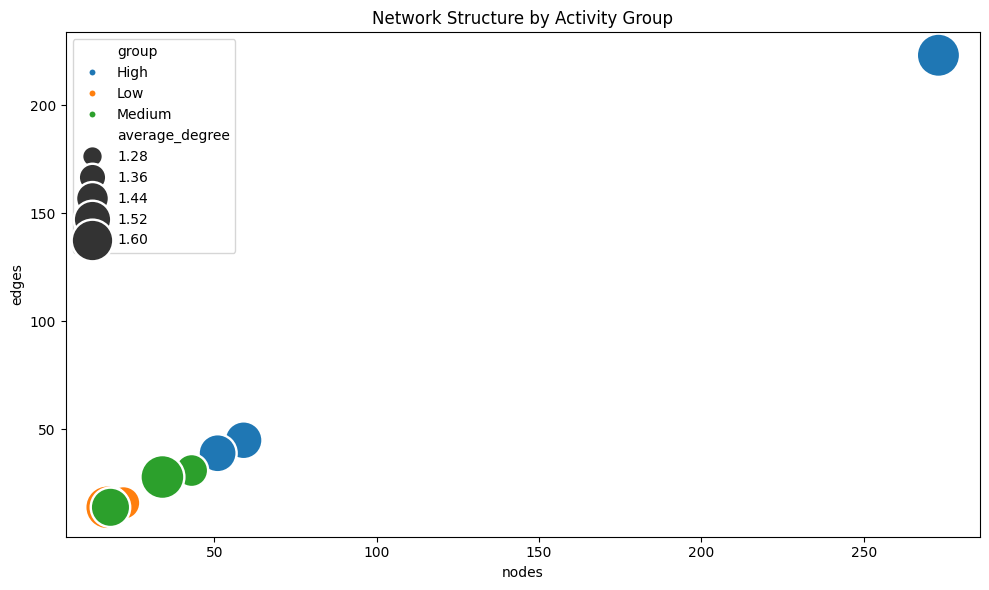

In [124]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=city_metrics_df,
    x="nodes",
    y="edges",
    hue="group",
    size="average_degree",
    sizes=(100,1000)
)

plt.title(
    "Network Structure by Activity Group"
)

plt.tight_layout()
plt.show()

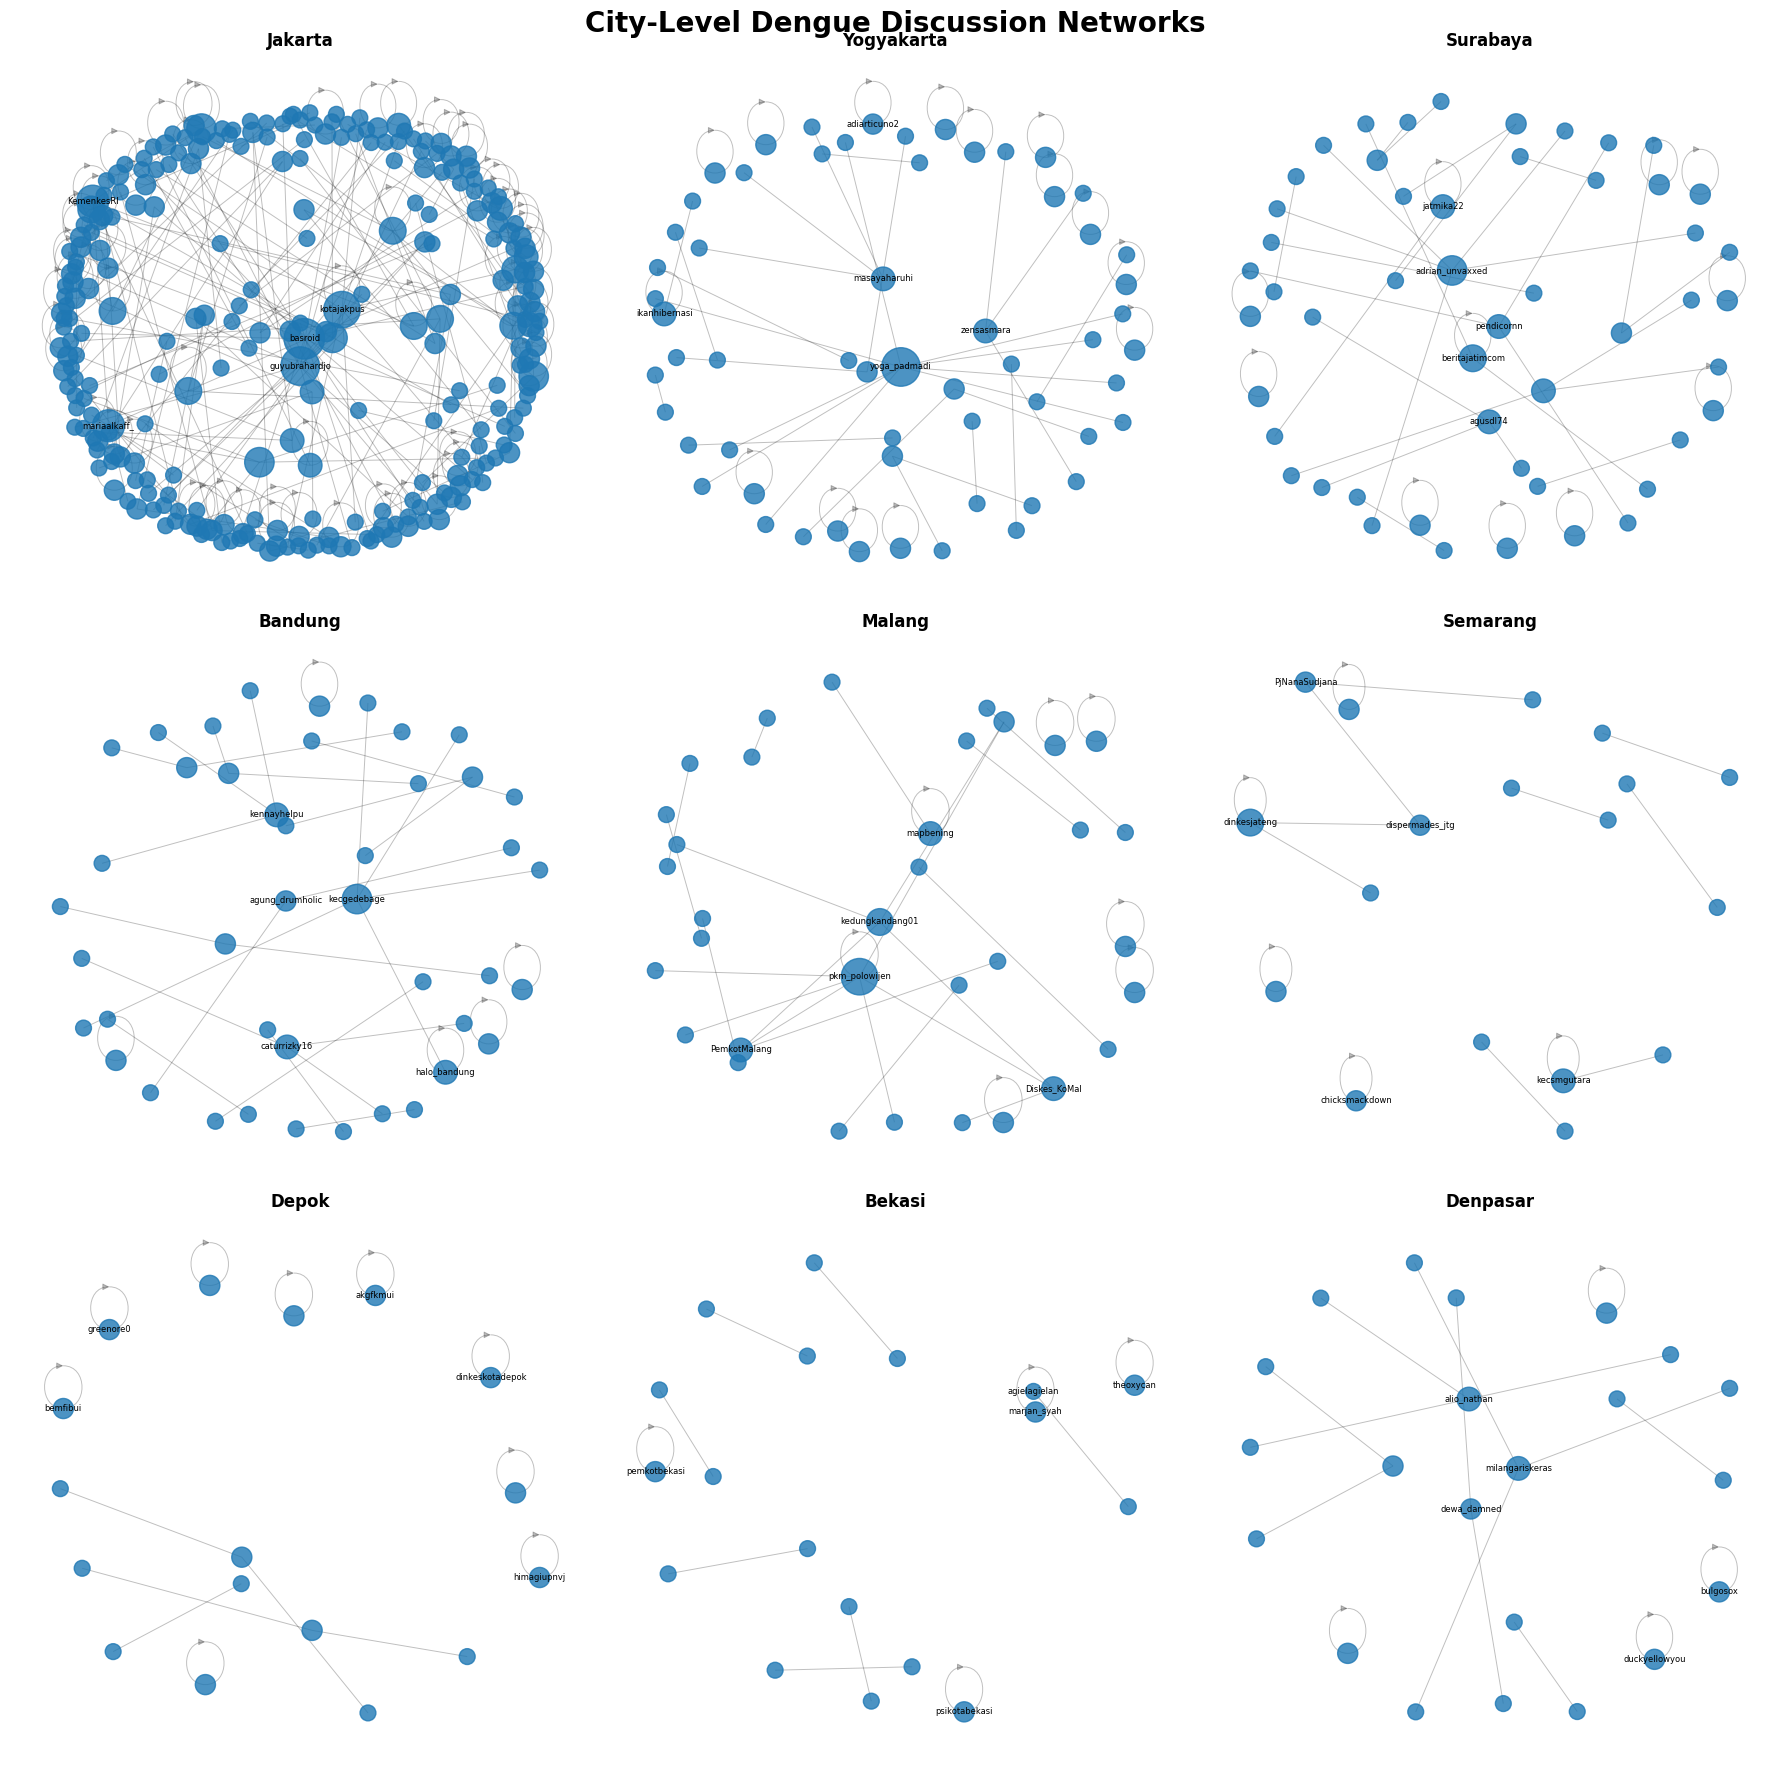

In [125]:
import matplotlib.pyplot as plt
import networkx as nx

fig, axes = plt.subplots(
    3,
    3,
    figsize=(18,18)
)

axes = axes.flatten()

for i, city in enumerate(
    selected_cities["city"]
):

    city_edges = (
        edges_city[
            edges_city["city_source"] == city
        ]
        .copy()
    )

    G_city = nx.from_pandas_edgelist(
        city_edges,
        source="source",
        target="target",
        edge_attr="weight",
        create_using=nx.DiGraph()
    )

    ax = axes[i]

    pos = nx.spring_layout(
        G_city,
        seed=42,
        k=0.8
    )

    degree = dict(
        G_city.degree()
    )

    node_sizes = [
        degree[n] * 80 + 50
        for n in G_city.nodes()
    ]

    nx.draw_networkx_nodes(
        G_city,
        pos,
        node_size=node_sizes,
        alpha=0.8,
        ax=ax
    )

    nx.draw_networkx_edges(
        G_city,
        pos,
        alpha=0.25,
        width=0.7,
        arrows=False,
        ax=ax
    )

    # label top 5 influencer
    top_nodes = sorted(
        degree,
        key=degree.get,
        reverse=True
    )[:5]

    nx.draw_networkx_labels(
        G_city,
        pos,
        labels={
            n:n
            for n in top_nodes
        },
        font_size=6,
        ax=ax
    )

    ax.set_title(
        city.title(),
        fontsize=12,
        weight="bold"
    )

    ax.axis("off")

plt.suptitle(
    "City-Level Dengue Discussion Networks",
    fontsize=20,
    weight="bold"
)

plt.tight_layout()

plt.savefig(
    "city_networks_3x3.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

---------------------TOP INFLUENCER BY CITY---------------------------------

Complete Network

In [41]:
import pandas as pd
import networkx as nx

top_influencers_city = []

for city in selected_cities["city"]:

    print(f"Processing {city}...")

    city_edges = (
        edges_city[
            edges_city["city_source"] == city
        ]
        .copy()
    )

    if len(city_edges) == 0:
        continue

    G_city = nx.from_pandas_edgelist(
        city_edges,
        source="source",
        target="target",
        edge_attr="weight",
        create_using=nx.DiGraph()
    )

    # Metrics

    pagerank = nx.pagerank(
        G_city,
        weight="weight"
    )

    in_degree = dict(
        G_city.in_degree()
    )

    out_degree = dict(
        G_city.out_degree()
    )

    betweenness = nx.betweenness_centrality(
        G_city,
        normalized=True
    )

    city_df = pd.DataFrame({

        "username":
            list(
                G_city.nodes()
            ),

        "pagerank":
            [
                pagerank.get(n,0)
                for n in G_city.nodes()
            ],

        "in_degree":
            [
                in_degree.get(n,0)
                for n in G_city.nodes()
            ],

        "out_degree":
            [
                out_degree.get(n,0)
                for n in G_city.nodes()
            ],

        "betweenness":
            [
                betweenness.get(n,0)
                for n in G_city.nodes()
            ]
    })

    city_df["city"] = city

    city_df = city_df.sort_values(
        "pagerank",
        ascending=False
    )

    city_df["rank"] = range(
        1,
        len(city_df)+1
    )

    top_influencers_city.append(
        city_df.head(10)
    )

top_influencers_city = pd.concat(
    top_influencers_city,
    ignore_index=True
)

top_influencers_city.head()

Processing jakarta...
Processing yogyakarta...
Processing surabaya...
Processing bandung...
Processing malang...
Processing semarang...
Processing depok...
Processing bekasi...
Processing denpasar...


,username,pagerank,in_degree,out_degree,betweenness,city,rank
0,teeadnu,0.009687,1,1,0.0,jakarta,1
1,sissssr110,0.009687,1,1,0.0,jakarta,2
2,ayosehatkemkes,0.009687,1,1,0.0,jakarta,3
3,awanmalangit,0.009687,1,1,0.0,jakarta,4
4,rspondokindah,0.009687,1,1,0.0,jakarta,5


In [42]:
top5_city = (
    top_influencers_city
    .groupby("city")
    .head(5)
)

top5_city

,username,pagerank,in_degree,out_degree,betweenness,city,rank
0,teeadnu,0.009687,1,1,0.0,jakarta,1
1,sissssr110,0.009687,1,1,0.0,jakarta,2
2,ayosehatkemkes,0.009687,1,1,0.0,jakarta,3
3,awanmalangit,0.009687,1,1,0.0,jakarta,4
4,rspondokindah,0.009687,1,1,0.0,jakarta,5
10,adiarticuno2,0.043939,1,1,0.0,yogyakarta,1
11,anotherorion,0.043939,1,1,0.0,yogyakarta,2
12,bentangpustaka,0.043939,1,1,0.0,yogyakarta,3
13,bukumojok,0.043939,1,1,0.0,yogyakarta,4
14,harian_jogja,0.043939,1,1,0.0,yogyakarta,5


In [43]:
top1_city = (
    top_influencers_city
    .groupby("city")
    .head(1)
)

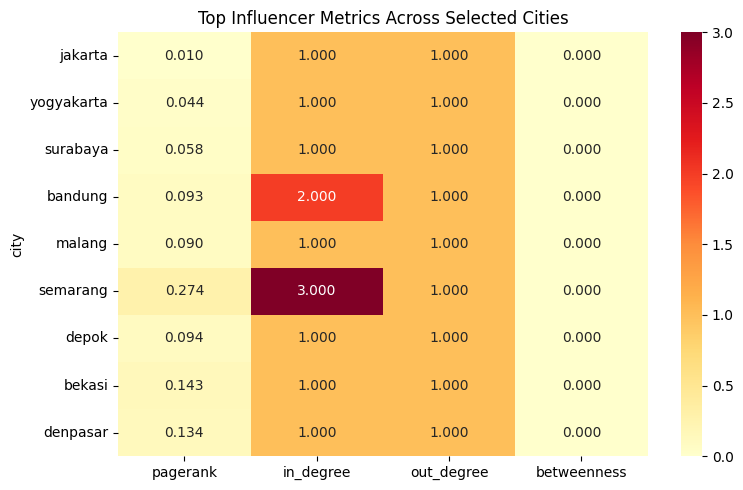

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_data = (
    top1_city[
        [
            "city",
            "pagerank",
            "in_degree",
            "out_degree",
            "betweenness"
        ]
    ]
    .set_index("city")
)

plt.figure(
    figsize=(8,5)
)

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="YlOrRd",
    fmt=".3f"
)

plt.title(
    "Top Influencer Metrics Across Selected Cities"
)

plt.tight_layout()
plt.show()

In [ ]:
top_influencers_city.to_excel(
    os.path.join(OUTPUT_DIR, "top_influencers_by_city.xlsx"),
    index=False
)

In [ ]:
top5_city.to_excel(
    os.path.join(OUTPUT_DIR, "top5_city.xlsx"),
    index=False
)
top5_city

,username,pagerank,in_degree,out_degree,betweenness,city,rank
0,teeadnu,0.009687,1,1,0.0,jakarta,1
1,sissssr110,0.009687,1,1,0.0,jakarta,2
2,ayosehatkemkes,0.009687,1,1,0.0,jakarta,3
3,awanmalangit,0.009687,1,1,0.0,jakarta,4
4,rspondokindah,0.009687,1,1,0.0,jakarta,5
10,adiarticuno2,0.043939,1,1,0.0,yogyakarta,1
11,anotherorion,0.043939,1,1,0.0,yogyakarta,2
12,bentangpustaka,0.043939,1,1,0.0,yogyakarta,3
13,bukumojok,0.043939,1,1,0.0,yogyakarta,4
14,harian_jogja,0.043939,1,1,0.0,yogyakarta,5


Neutral Network

In [47]:
neutral_edges = (
    edges_data[
        edges_data["sentiment"] == "neutral"
    ]
    .copy()
)

In [48]:
neutral_edges_city = neutral_edges.merge(
    user_city,
    left_on="source",
    right_on="username",
    how="left"
)

neutral_edges_city = neutral_edges_city.rename(
    columns={
        "city_clean":"city_source"
    }
)

neutral_edges_city = neutral_edges_city.drop(
    columns=["username"]
)

In [49]:
neutral_edges_city = neutral_edges_city.merge(
    user_city,
    left_on="target",
    right_on="username",
    how="left"
)

neutral_edges_city = neutral_edges_city.rename(
    columns={
        "city_clean":"city_target"
    }
)

neutral_edges_city = neutral_edges_city.drop(
    columns=["username"]
)

In [50]:
import pandas as pd
import networkx as nx

top_neutral_influencers_city = []

for city in selected_cities["city"]:

    print(f"Processing {city}...")

    city_edges = (
        neutral_edges_city[
            neutral_edges_city["city_source"] == city
        ]
        .copy()
    )

    if len(city_edges) == 0:
        continue

    G_city = nx.from_pandas_edgelist(
        city_edges,
        source="source",
        target="target",
        edge_attr="weight",
        create_using=nx.DiGraph()
    )

    pagerank = nx.pagerank(
        G_city,
        weight="weight"
    )

    in_degree = dict(
        G_city.in_degree()
    )

    out_degree = dict(
        G_city.out_degree()
    )

    betweenness = nx.betweenness_centrality(
        G_city,
        normalized=True
    )

    city_df = pd.DataFrame({

        "username":
            list(
                G_city.nodes()
            ),

        "pagerank":
            [
                pagerank.get(n,0)
                for n in G_city.nodes()
            ],

        "in_degree":
            [
                in_degree.get(n,0)
                for n in G_city.nodes()
            ],

        "out_degree":
            [
                out_degree.get(n,0)
                for n in G_city.nodes()
            ],

        "betweenness":
            [
                betweenness.get(n,0)
                for n in G_city.nodes()
            ]
    })

    city_df["city"] = city

    city_df = city_df.sort_values(
        "pagerank",
        ascending=False
    )

    city_df["rank"] = range(
        1,
        len(city_df)+1
    )

    top_neutral_influencers_city.append(
        city_df.head(10)
    )

top_neutral_influencers_city = pd.concat(
    top_neutral_influencers_city,
    ignore_index=True
)

Processing jakarta...
Processing yogyakarta...
Processing surabaya...
Processing bandung...
Processing malang...
Processing semarang...
Processing depok...
Processing bekasi...
Processing denpasar...


In [ ]:
top_neutral_influencers_city.to_excel(
    os.path.join(OUTPUT_DIR, "top_neutral_influencers_by_city.xlsx"),
    index=False
)

In [52]:
top5_neutral_city = (
    top_neutral_influencers_city
    .groupby("city")
    .head(5)
)

top5_neutral_city

,username,pagerank,in_degree,out_degree,betweenness,city,rank
0,almi_indonesia,0.019151,1,1,0.0,jakarta,1
1,allianzid,0.019151,1,1,0.0,jakarta,2
2,antiborju,0.019151,1,1,0.0,jakarta,3
3,bemfikesuhamka,0.019151,1,1,0.0,jakarta,4
4,bempolimediajkt,0.019151,1,1,0.0,jakarta,5
10,anotherorion,0.068316,1,1,0.0,yogyakarta,1
11,bukumojok,0.068316,1,1,0.0,yogyakarta,2
12,harian_jogja,0.068316,1,1,0.0,yogyakarta,3
13,kominfodiy,0.068316,1,1,0.0,yogyakarta,4
14,jmkifarmasiuad,0.068316,1,1,0.0,yogyakarta,5


In [ ]:
top5_neutral_city.to_excel(
    os.path.join(OUTPUT_DIR, "top5_neutral_city.xlsx"),
    index=False
)

Positive Network

In [54]:
positive_edges = (
    edges_data[
        edges_data["sentiment"] == "positive"
    ]
    .copy()
)

In [55]:
positive_edges_city = positive_edges.merge(
    user_city,
    left_on="source",
    right_on="username",
    how="left"
)

positive_edges_city = positive_edges_city.rename(
    columns={
        "city_clean":"city_source"
    }
)

positive_edges_city = positive_edges_city.drop(
    columns=["username"]
)

In [56]:
positive_edges_city = positive_edges_city.merge(
    user_city,
    left_on="target",
    right_on="username",
    how="left"
)

positive_edges_city = positive_edges_city.rename(
    columns={
        "city_clean":"city_target"
    }
)

positive_edges_city = positive_edges_city.drop(
    columns=["username"]
)

In [57]:
import pandas as pd
import networkx as nx

top_positive_influencers_city = []

for city in selected_cities["city"]:

    print(f"Processing {city}...")

    city_edges = (
        positive_edges_city[
            positive_edges_city["city_source"] == city
        ]
        .copy()
    )

    if len(city_edges) == 0:
        continue

    G_city = nx.from_pandas_edgelist(
        city_edges,
        source="source",
        target="target",
        edge_attr="weight",
        create_using=nx.DiGraph()
    )

    # Centrality Metrics

    pagerank = nx.pagerank(
        G_city,
        weight="weight"
    )

    in_degree = dict(
        G_city.in_degree()
    )

    out_degree = dict(
        G_city.out_degree()
    )

    betweenness = nx.betweenness_centrality(
        G_city,
        normalized=True
    )

    city_df = pd.DataFrame({

        "username":
            list(G_city.nodes()),

        "pagerank":
            [
                pagerank.get(n,0)
                for n in G_city.nodes()
            ],

        "in_degree":
            [
                in_degree.get(n,0)
                for n in G_city.nodes()
            ],

        "out_degree":
            [
                out_degree.get(n,0)
                for n in G_city.nodes()
            ],

        "betweenness":
            [
                betweenness.get(n,0)
                for n in G_city.nodes()
            ]
    })

    city_df["city"] = city

    city_df["network"] = "Positive"

    city_df = city_df.sort_values(
        "pagerank",
        ascending=False
    )

    city_df["rank"] = range(
        1,
        len(city_df)+1
    )

    top_positive_influencers_city.append(
        city_df.head(10)
    )

top_positive_influencers_city = pd.concat(
    top_positive_influencers_city,
    ignore_index=True
)

Processing jakarta...
Processing yogyakarta...
Processing surabaya...
Processing bandung...
Processing malang...
Processing semarang...
Processing depok...
Processing bekasi...
Processing denpasar...


In [ ]:
top_positive_influencers_city.to_excel(
    os.path.join(OUTPUT_DIR, "top_positive_influencers_by_city.xlsx"),
    index=False
)

In [59]:
top5_positive_city = (
    top_positive_influencers_city
    .groupby("city")
    .head(5)
)

top5_positive_city

,username,pagerank,in_degree,out_degree,betweenness,city,network,rank
0,bkpkkemenkes,0.029577,1,1,0.0,jakarta,Positive,1
1,bempolimediajkt,0.029577,1,1,0.0,jakarta,Positive,2
2,asuransimag_,0.029577,1,1,0.0,jakarta,Positive,3
3,ptdahana,0.029577,1,1,0.0,jakarta,Positive,4
4,pidas_81,0.029577,1,1,0.0,jakarta,Positive,5
10,anotherorion,0.142857,1,1,0.0,yogyakarta,Positive,1
11,bentangpustaka,0.142857,1,1,0.0,yogyakarta,Positive,2
12,bukumojok,0.142857,1,1,0.0,yogyakarta,Positive,3
13,harian_jogja,0.142857,1,1,0.0,yogyakarta,Positive,4
14,sahabatganjarid,0.142857,1,1,0.0,yogyakarta,Positive,5


In [ ]:
top5_positive_city.to_excel(
    os.path.join(OUTPUT_DIR, "top5_positive_city.xlsx"),
    index=False
)

Negative

In [61]:
negative_edges = (
    edges_data[
        edges_data["sentiment"] == "negative"
    ]
    .copy()
)

In [62]:
negative_edges_city = negative_edges.merge(
    user_city,
    left_on="source",
    right_on="username",
    how="left"
)

negative_edges_city = negative_edges_city.rename(
    columns={
        "city_clean":"city_source"
    }
)

negative_edges_city = negative_edges_city.drop(
    columns=["username"]
)

In [63]:
negative_edges_city = negative_edges_city.merge(
    user_city,
    left_on="target",
    right_on="username",
    how="left"
)

negative_edges_city = negative_edges_city.rename(
    columns={
        "city_clean":"city_target"
    }
)

negative_edges_city = negative_edges_city.drop(
    columns=["username"]
)

In [64]:
import pandas as pd
import networkx as nx

top_negative_influencers_city = []

for city in selected_cities["city"]:

    print(f"Processing {city}...")

    city_edges = (
        negative_edges_city[
            negative_edges_city["city_source"] == city
        ]
        .copy()
    )

    if len(city_edges) == 0:
        continue

    G_city = nx.from_pandas_edgelist(
        city_edges,
        source="source",
        target="target",
        edge_attr="weight",
        create_using=nx.DiGraph()
    )

    # ======================
    # Centrality Metrics
    # ======================

    pagerank = nx.pagerank(
        G_city,
        weight="weight"
    )

    in_degree = dict(
        G_city.in_degree()
    )

    out_degree = dict(
        G_city.out_degree()
    )

    betweenness = nx.betweenness_centrality(
        G_city,
        normalized=True
    )

    city_df = pd.DataFrame({

        "username":
            list(G_city.nodes()),

        "pagerank":
            [
                pagerank.get(n,0)
                for n in G_city.nodes()
            ],

        "in_degree":
            [
                in_degree.get(n,0)
                for n in G_city.nodes()
            ],

        "out_degree":
            [
                out_degree.get(n,0)
                for n in G_city.nodes()
            ],

        "betweenness":
            [
                betweenness.get(n,0)
                for n in G_city.nodes()
            ]
    })

    city_df["city"] = city

    city_df["network"] = "Negative"

    city_df = city_df.sort_values(
        "pagerank",
        ascending=False
    )

    city_df["rank"] = range(
        1,
        len(city_df)+1
    )

    top_negative_influencers_city.append(
        city_df.head(10)
    )

top_negative_influencers_city = pd.concat(
    top_negative_influencers_city,
    ignore_index=True
)

Processing jakarta...
Processing yogyakarta...
Processing surabaya...
Processing bandung...
Processing malang...
Processing semarang...
Processing depok...
Processing bekasi...
Processing denpasar...


In [ ]:
top_negative_influencers_city.to_excel(
    os.path.join(OUTPUT_DIR, "top_negative_influencers_by_city.xlsx"),
    index=False
)

In [66]:
top5_negative_city = (
    top_negative_influencers_city
    .groupby("city")
    .head(5)
)

top5_negative_city

,username,pagerank,in_degree,out_degree,betweenness,city,network,rank
0,asmurcom,0.023722,1,1,0.0,jakarta,Negative,1
1,awanmalangit,0.023722,1,1,0.0,jakarta,Negative,2
2,ayosehatkemkes,0.023722,1,1,0.0,jakarta,Negative,3
3,evi_fadliah,0.023722,1,1,0.0,jakarta,Negative,4
4,farmaku,0.023722,1,1,0.0,jakarta,Negative,5
10,adiarticuno2,0.109649,1,1,0.0,yogyakarta,Negative,1
11,anotherorion,0.109649,1,1,0.0,yogyakarta,Negative,2
12,bukumojok,0.109649,1,1,0.0,yogyakarta,Negative,3
13,kominfodiy,0.109649,1,1,0.0,yogyakarta,Negative,4
14,valiisaa,0.030432,1,0,0.0,yogyakarta,Negative,5


In [ ]:
top5_negative_city.to_excel(
    os.path.join(OUTPUT_DIR, "top5_negative_city.xlsx"),
    index=False
)

In [68]:
all_city_influencers = pd.concat([

    top_influencers_city,

    top_positive_influencers_city,

    top_neutral_influencers_city,

    top_negative_influencers_city

], ignore_index=True)

all_city_influencers

,username,pagerank,in_degree,out_degree,betweenness,city,rank,network
0,teeadnu,0.009687,1,1,0.0,jakarta,1,NaN
1,sissssr110,0.009687,1,1,0.0,jakarta,2,NaN
2,ayosehatkemkes,0.009687,1,1,0.0,jakarta,3,NaN
3,awanmalangit,0.009687,1,1,0.0,jakarta,4,NaN
4,rspondokindah,0.009687,1,1,0.0,jakarta,5,NaN
...,...,...,...,...,...,...,...,...
310,ProfesorZubairi,0.111111,1,0,0.0,denpasar,5,Negative
311,WA_ynym,0.111111,1,0,0.0,denpasar,6,Negative
312,lunazi_,0.086580,0,1,0.0,denpasar,7,Negative
313,milangariskeras,0.086580,0,3,0.0,denpasar,8,Negative
